In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
dados_d = pd.read_csv('./dados/dengue_tratado.csv')
dados_ch = pd.read_csv('./dados/chikungunya_tratado.csv')
dados_zk = pd.read_csv('./dados/zika_tratado.csv')

In [3]:
dados_d['data_iniSE'] = pd.to_datetime(dados_d['data_iniSE'])
dados_d = dados_d.set_index('data_iniSE')

dados_ch['data_iniSE'] = pd.to_datetime(dados_ch['data_iniSE'])
dados_ch = dados_ch.set_index('data_iniSE')

dados_zk['data_iniSE'] = pd.to_datetime(dados_zk['data_iniSE'])
dados_zk = dados_zk.set_index('data_iniSE')

In [4]:
def media_movel_walk_forward(serie, lags=6, horizon=6, step=6):
    predictions = []
    actuals = []
    datas = []

    for i in range(lags, len(serie) - horizon + 1, step):
        ma_value = serie.iloc[i-lags:i].mean()
        forecast = [ma_value] * horizon
        bloco = serie.iloc[i:i+horizon]

        predictions.extend(forecast)
        actuals.extend(bloco.values)
        datas.extend(bloco.index)

    return pd.DataFrame(actuals, index=datas, columns=["y"]), pd.DataFrame(predictions, index=datas, columns=["y_pred"])

In [5]:
reais_d, previsoes_d = media_movel_walk_forward(dados_d['casos'], 6,6,6)
reais_ch, previsoes_ch = media_movel_walk_forward(dados_ch['casos'], 6,6,6)
reais_zk, previsoes_zk = media_movel_walk_forward(dados_zk['casos'], 6,6,6)

In [6]:
def avaliar_normalizado(y_predito, y_test):
    y_predito = np.array(y_predito).ravel()
    y_test = np.array(y_test).ravel()

    mae = mean_absolute_error(y_test, y_predito)
    rmse = root_mean_squared_error(y_test, y_predito)
    r2 = r2_score(y_test, y_predito)

    des_padrao = np.std(y_test)
    nmae = mae / des_padrao
    nrmse = rmse / des_padrao


    print(f"MAE:  {nmae:.2f}")
    print(f"RMSE: {nrmse:.2f}")
    print(f"R²:   {r2:.4f}")

In [7]:
avaliar_normalizado(reais_d, previsoes_d)

MAE:  0.26
RMSE: 0.88
R²:   0.2249


In [8]:
avaliar_normalizado(reais_ch, previsoes_ch)

MAE:  0.25
RMSE: 1.14
R²:   -0.2919


In [9]:
avaliar_normalizado(reais_zk, previsoes_zk)

MAE:  0.23
RMSE: 1.09
R²:   -0.1804


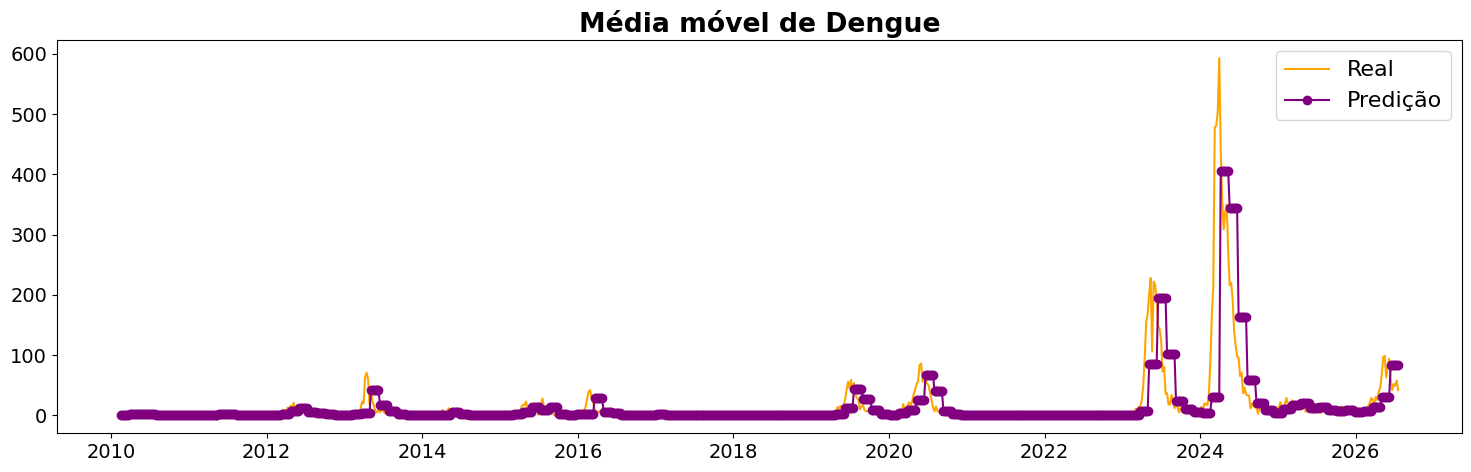

In [10]:
plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 16})

plt.title("Média móvel de Dengue", fontweight='bold')
plt.plot(reais_d, color="orange", label="Real")
plt.plot(previsoes_d, color="purple", marker="o", label="Predição")
plt.legend()
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('./graficos/MEDMOV_Dengue.png', bbox_inches='tight', dpi=300)
plt.show()

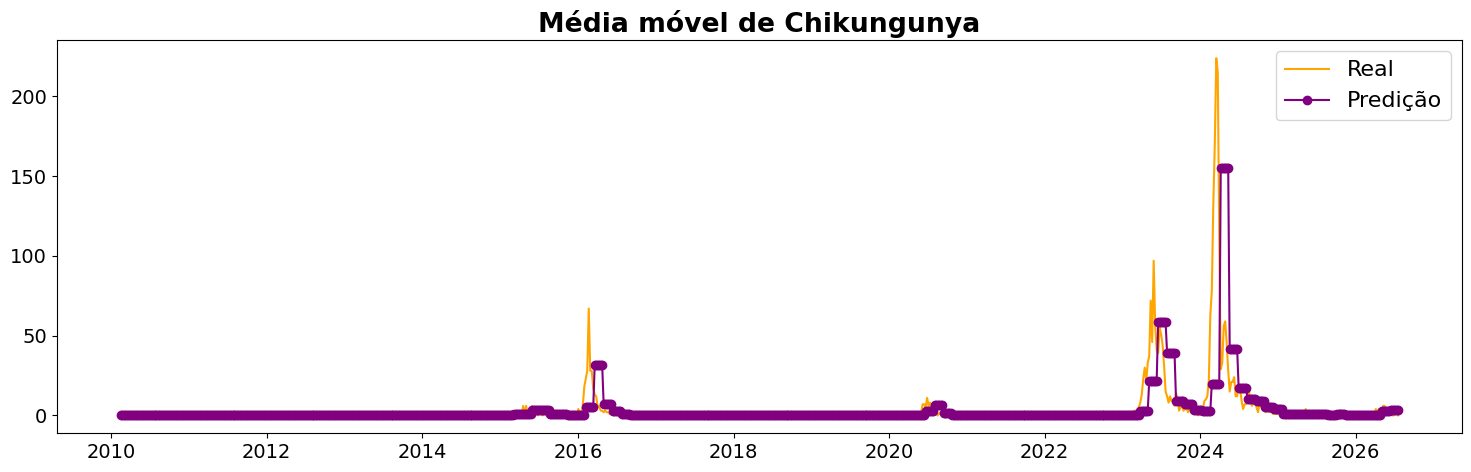

In [11]:
plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 16})

plt.title("Média móvel de Chikungunya", fontweight='bold')
plt.plot(reais_ch, color="orange", label="Real")
plt.plot(previsoes_ch, color="purple", marker="o", label="Predição")
plt.legend()
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('./graficos/MEDMOV_Chikungunya.png', bbox_inches='tight', dpi=300)
plt.show()

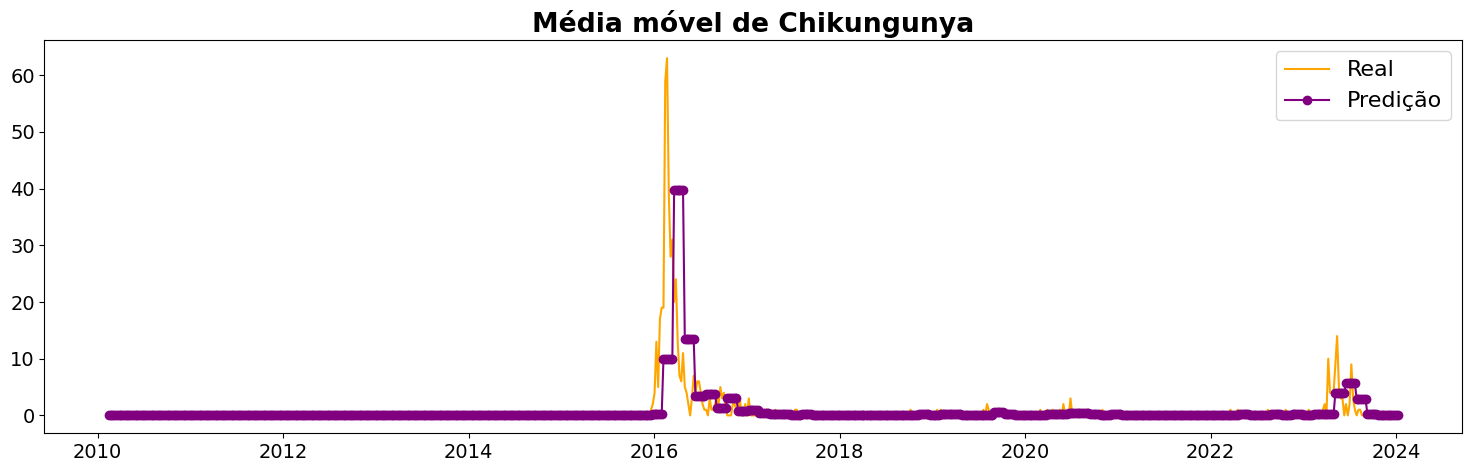

In [12]:
plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 16})

plt.title("Média móvel de Chikungunya", fontweight='bold')
plt.plot(reais_zk, color="orange", label="Real")
plt.plot(previsoes_zk, color="purple", marker="o", label="Predição")
plt.legend()
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('./graficos/MEDMOV_Zika.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
def salar_dataFrames(reais, previsoes, arbo, modelo, caminho):
    dados = pd.merge(reais, previsoes, on=reais.index)
    dados = dados.rename(columns={"key_0": "data"})
    dados.index = pd.to_datetime(dados["data"])
    dados = dados.drop("data", axis=1)
    dados.to_csv(f"{caminho}/{modelo}_{arbo}.csv", index=True)

In [56]:
salar_dataFrames(reais_d, previsoes_d, "Dengue", "MedMov", "./resultados/medmov")
salar_dataFrames(reais_ch, previsoes_ch, "Chikungunya", "MedMov", "./resultados/medmov")
salar_dataFrames(reais_zk, previsoes_zk, "Zika", "MedMov", "./resultados/medmov")